In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import SVG

from vizopt.animation import SnapshotCallback, snapshots_to_animated_svg
from vizopt.base import OptimConfig
from vizopt.templates.euler.stars_vs_circles import (
    optimize_radially_convex_sets_and_circles_from_graph,
)
from vizopt.examples.sets import make_animals_graph, make_multiples_of_primes_graph
from vizopt.schedules import make_term_schedules

# Sets of multiples

In [2]:
primes = [2, 3, 5]
G = make_multiples_of_primes_graph(primes)
elements = sorted(n for n in G.nodes if G.out_degree(n) == 0)

In [3]:
n_iters = 8000
best_params = {
    "collision_delay": 0.27,
    "collision_ramp":  0.33,
    "exclusion_delay": 0.32,
    "exclusion_ramp":  0.47,
    "area_delay":      0.31,
    "area_ramp":       0.27,
    "perimeter_delay": 0.69,
    "perimeter_ramp":  0.45,
    "attraction_peak": 0.69,
    "attraction_ramp": 0.18,
}
term_schedules = make_term_schedules(best_params, n_iters)

In [ ]:
snapshot_cb = SnapshotCallback(every=50)

named_results, named_circles_out, history, problem = optimize_radially_convex_sets_and_circles_from_graph(
    G,
    weight_area=1.0,
    weight_perimeter=1.0,
    weight_exclusion=10.0,
    weight_smoothness=2.0,
    weight_position_anchor=0.3,
    weight_circle_collision=20.0,
    weight_set_attraction=5.0,
    term_schedules=term_schedules,
    optim_config=OptimConfig(n_iters=n_iters, learning_rate=0.002),
    callback=snapshot_cb,
)
print(f"Captured {len(snapshot_cb.snapshots)} snapshots")

Iteration 0: loss = 1980.2845458984375
Iteration 100: loss = 1167.5928955078125
Iteration 200: loss = 948.3883666992188
Iteration 300: loss = 762.1444702148438
Iteration 400: loss = 493.2304382324219
Iteration 500: loss = 361.6980895996094
Iteration 600: loss = 287.73822021484375
Iteration 700: loss = 237.1505889892578
Iteration 800: loss = 203.25421142578125
Iteration 900: loss = 180.59320068359375
Iteration 1000: loss = 162.38198852539062
Iteration 1100: loss = 147.40081787109375
Iteration 1200: loss = 135.27577209472656
Iteration 1300: loss = 124.76013946533203
Iteration 1400: loss = 116.19802856445312
Iteration 1500: loss = 110.84473419189453
Iteration 1600: loss = 103.42665100097656
Iteration 1700: loss = 98.50643157958984
Iteration 1800: loss = 94.52582550048828
Iteration 1900: loss = 91.1063461303711
Iteration 2000: loss = 87.64727783203125
Iteration 2100: loss = 85.14765167236328
Iteration 2200: loss = 83.26441192626953
Iteration 2300: loss = 81.18946838378906
Iteration 2400: l

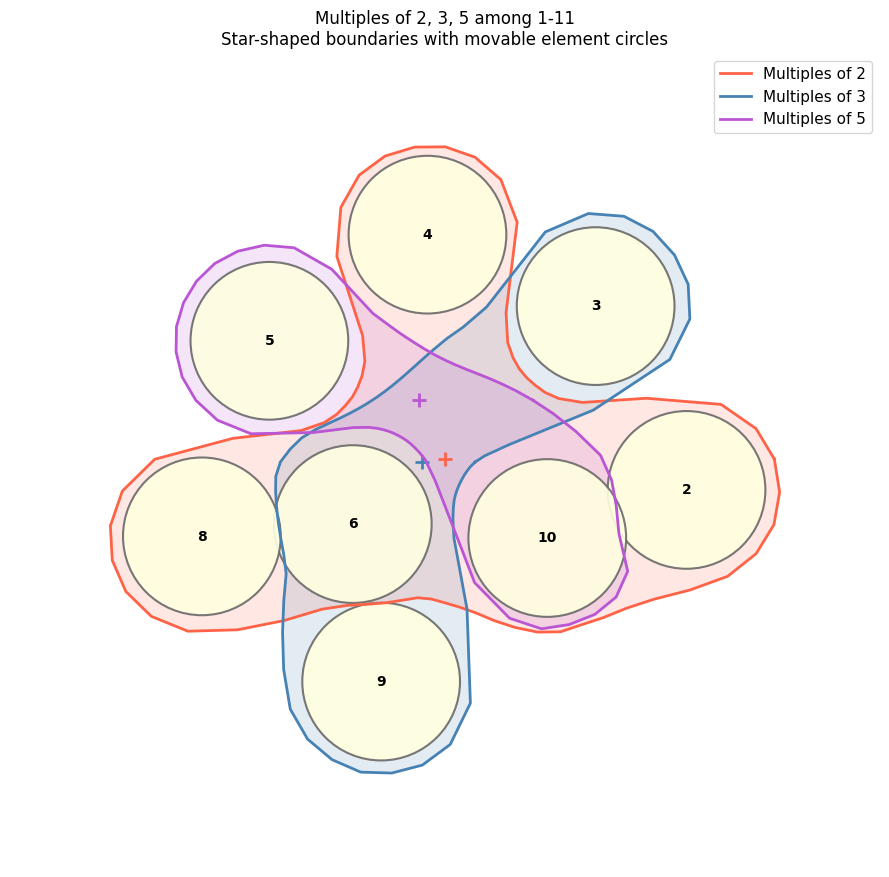

In [5]:
set_colors = ["tomato", "steelblue", "mediumorchid", "mediumseagreen"]
set_node_names = [f"multiples_of_{p}" for p in primes]
set_labels = [f"Multiples of {p}" for p in primes]

fig, ax = plt.subplots(figsize=(9, 9))

for set_name, color, label in zip(set_node_names, set_colors, set_labels):
    result = named_results[set_name]
    cx, cy = result["center"]
    radii = result["radii"]
    angles = result["angles"]
    bx = np.append(cx + radii * np.cos(angles), cx + radii[0] * np.cos(angles[0]))
    by = np.append(cy + radii * np.sin(angles), cy + radii[0] * np.sin(angles[0]))
    ax.fill(bx, by, alpha=0.15, color=color)
    ax.plot(bx, by, color=color, linewidth=2, label=label)
    ax.plot(cx, cy, "+", color=color, markersize=10, markeredgewidth=2)

for n in elements:
    r_orig = G.nodes[n]["r"]
    cx_out, cy_out, _ = named_circles_out[n]
    ax.add_patch(plt.Circle((cx_out, cy_out), r_orig, facecolor="lightyellow", alpha=0.9,
                            edgecolor="dimgray", linewidth=1.5))
    ax.text(cx_out, cy_out, str(n), ha="center", va="center", fontsize=10, fontweight="bold")

ax.set_aspect("equal")
ax.autoscale_view()
ax.margins(0.15)
ax.legend(loc="upper right", fontsize=11)
ax.set_title("Multiples of 2, 3, 5 among 1-11\nStar-shaped boundaries with movable element circles")
ax.axis("off")
plt.tight_layout()

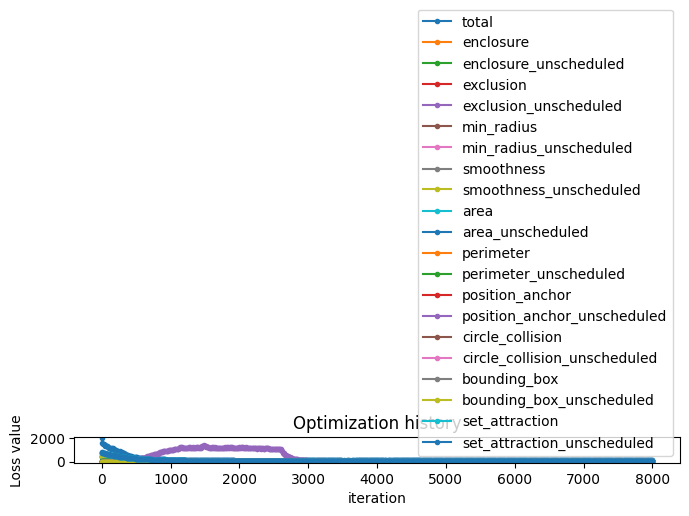

In [6]:
pd.DataFrame(history).set_index("iteration").plot(marker=".", figsize=(7, 3))
plt.ylabel("Loss value")
plt.title("Optimization history")
plt.tight_layout()

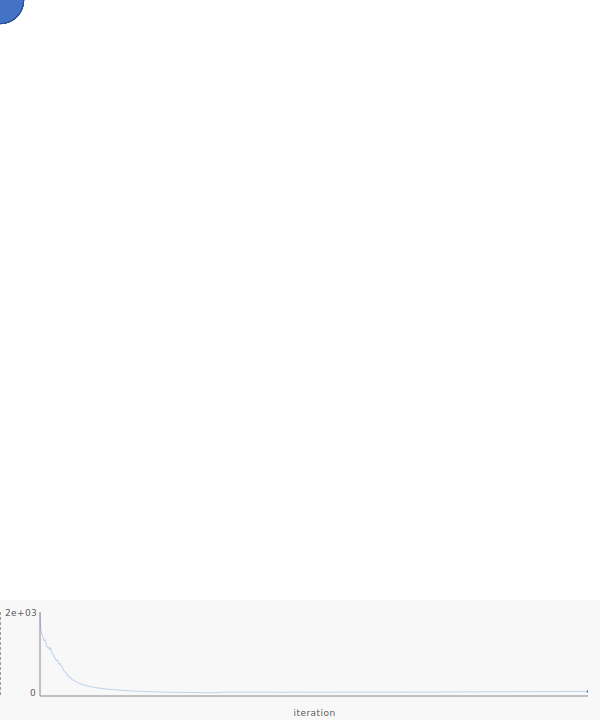

In [7]:
svg = snapshots_to_animated_svg(problem, snapshot_cb.snapshots, fps=5, size=600, history=history)
SVG(data=svg)

# Animals taxonomy

In [8]:
G_a = make_animals_graph()
elements_a = sorted(n for n in G_a.nodes if G_a.out_degree(n) == 0)
set_names_a = [n for n in G_a.nodes if G_a.out_degree(n) > 0]

In [ ]:
snapshot_cb_a = SnapshotCallback(every=50)

named_results_a, named_circles_a, history_a, problem_a = optimize_radially_convex_sets_and_circles_from_graph(
    G_a,
    weight_area=1.0,
    weight_perimeter=1.0,
    weight_exclusion=10.0,
    weight_smoothness=2.0,
    weight_position_anchor=0.3,
    weight_circle_collision=20.0,
    weight_set_attraction=5.0,
    term_schedules=term_schedules,
    optim_config=OptimConfig(n_iters=n_iters, learning_rate=0.002),
    callback=snapshot_cb_a,
)
print(f"Captured {len(snapshot_cb_a.snapshots)} snapshots")

Iteration 0: loss = 316.5028076171875
Iteration 100: loss = 191.8874969482422
Iteration 200: loss = 175.98814392089844
Iteration 300: loss = 138.22744750976562
Iteration 400: loss = 114.51728057861328
Iteration 500: loss = 97.8913803100586
Iteration 600: loss = 84.55579376220703
Iteration 700: loss = 73.18802642822266
Iteration 800: loss = 63.39616394042969
Iteration 900: loss = 54.95094299316406
Iteration 1000: loss = 47.7275390625
Iteration 1100: loss = 41.601139068603516
Iteration 1200: loss = 36.44700622558594
Iteration 1300: loss = 32.188751220703125
Iteration 1400: loss = 29.072683334350586
Iteration 1500: loss = 26.56431770324707
Iteration 1600: loss = 24.48971939086914
Iteration 1700: loss = 22.87109375
Iteration 1800: loss = 21.627370834350586
Iteration 1900: loss = 20.90902328491211
Iteration 2000: loss = 20.520492553710938
Iteration 2100: loss = 20.299583435058594
Iteration 2200: loss = 20.1490421295166
Iteration 2300: loss = 20.02836036682129
Iteration 2400: loss = 19.92851

TODO variable offset to distinguish sets
TODO set labeling in the figure

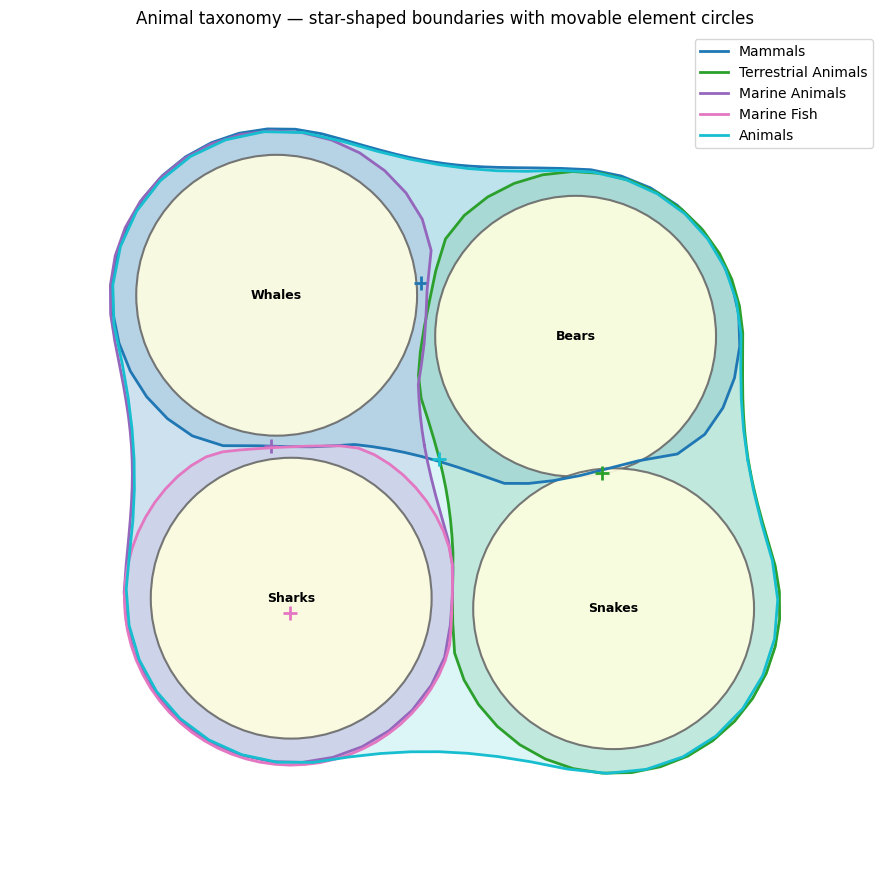

In [10]:
colors_a = plt.cm.tab10(np.linspace(0, 0.9, len(set_names_a)))

fig, ax = plt.subplots(figsize=(9, 9))

for set_name, color in zip(set_names_a, colors_a):
    result = named_results_a[set_name]
    cx, cy = result["center"]
    radii = result["radii"]
    angles = result["angles"]
    bx = np.append(cx + radii * np.cos(angles), cx + radii[0] * np.cos(angles[0]))
    by = np.append(cy + radii * np.sin(angles), cy + radii[0] * np.sin(angles[0]))
    ax.fill(bx, by, alpha=0.15, color=color)
    ax.plot(bx, by, color=color, linewidth=2, label=set_name)
    ax.plot(cx, cy, "+", color=color, markersize=10, markeredgewidth=2)

for n in elements_a:
    r_orig = G_a.nodes[n]["r"]
    cx_out, cy_out, _ = named_circles_a[n]
    ax.add_patch(plt.Circle((cx_out, cy_out), r_orig, facecolor="lightyellow", alpha=0.9,
                            edgecolor="dimgray", linewidth=1.5))
    ax.text(cx_out, cy_out, n, ha="center", va="center", fontsize=9, fontweight="bold")

ax.set_aspect("equal")
ax.autoscale_view()
ax.margins(0.15)
ax.legend(loc="upper right", fontsize=10)
ax.set_title("Animal taxonomy — star-shaped boundaries with movable element circles")
ax.axis("off")
plt.tight_layout()